# Bottleneck Analysis - BPI Challenge 2017

Mục tiêu của notebook này là làm rõ bottleneck theo thống kê trước khi vẽ DFG.

Tập trung vào các tuần 19, 24, 25 và 49 bằng các chỉ số:

- thời gian chờ giữa các sự kiện trong cùng một case
- thời gian hoàn thành case
- backlog / số case đang mở theo tuần
- tỷ lệ suspend / resume / ate_abort
- nhóm hoạt động nào chiếm nhiều thời gian nhất
- phân loại case theo dạng bottleneck để đọc dễ hơn

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")
OUTPUT_DIR = Path("../results/bottleneck_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the cleaned event log
# Keep all lifecycle transitions because bottleneck signals often live in start/suspend/resume/abort events.
df = pd.read_csv(DATA_PATH)
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")
df = df.dropna(subset=["time:timestamp"]).copy()
df = df.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)

df["year"] = df["time:timestamp"].dt.isocalendar().year.astype(int)
df["week"] = df["time:timestamp"].dt.isocalendar().week.astype(int)
df["gap_minutes"] = (
    df.groupby("case:concept:name")["time:timestamp"].shift(-1) - df["time:timestamp"]
).dt.total_seconds() / 60

print("Rows:", len(df))
print("Cases:", df["case:concept:name"].nunique())
print("Activities:", df["concept:name"].nunique())
print(df[["case:concept:name", "concept:name", "lifecycle:transition", "time:timestamp"]].head())

Rows: 1201090
Cases: 31509
Activities: 26
        case:concept:name            concept:name lifecycle:transition  \
0  Application_1000086665    A_Create Application             complete   
1  Application_1000086665             A_Submitted             complete   
2  Application_1000086665          W_Handle leads             schedule   
3  Application_1000086665          W_Handle leads             withdraw   
4  Application_1000086665  W_Complete application             schedule   

                    time:timestamp  
0 2016-08-03 15:57:21.673000+00:00  
1 2016-08-03 15:57:21.734000+00:00  
2 2016-08-03 15:57:21.963000+00:00  
3 2016-08-03 15:58:28.286000+00:00  
4 2016-08-03 15:58:28.293000+00:00  


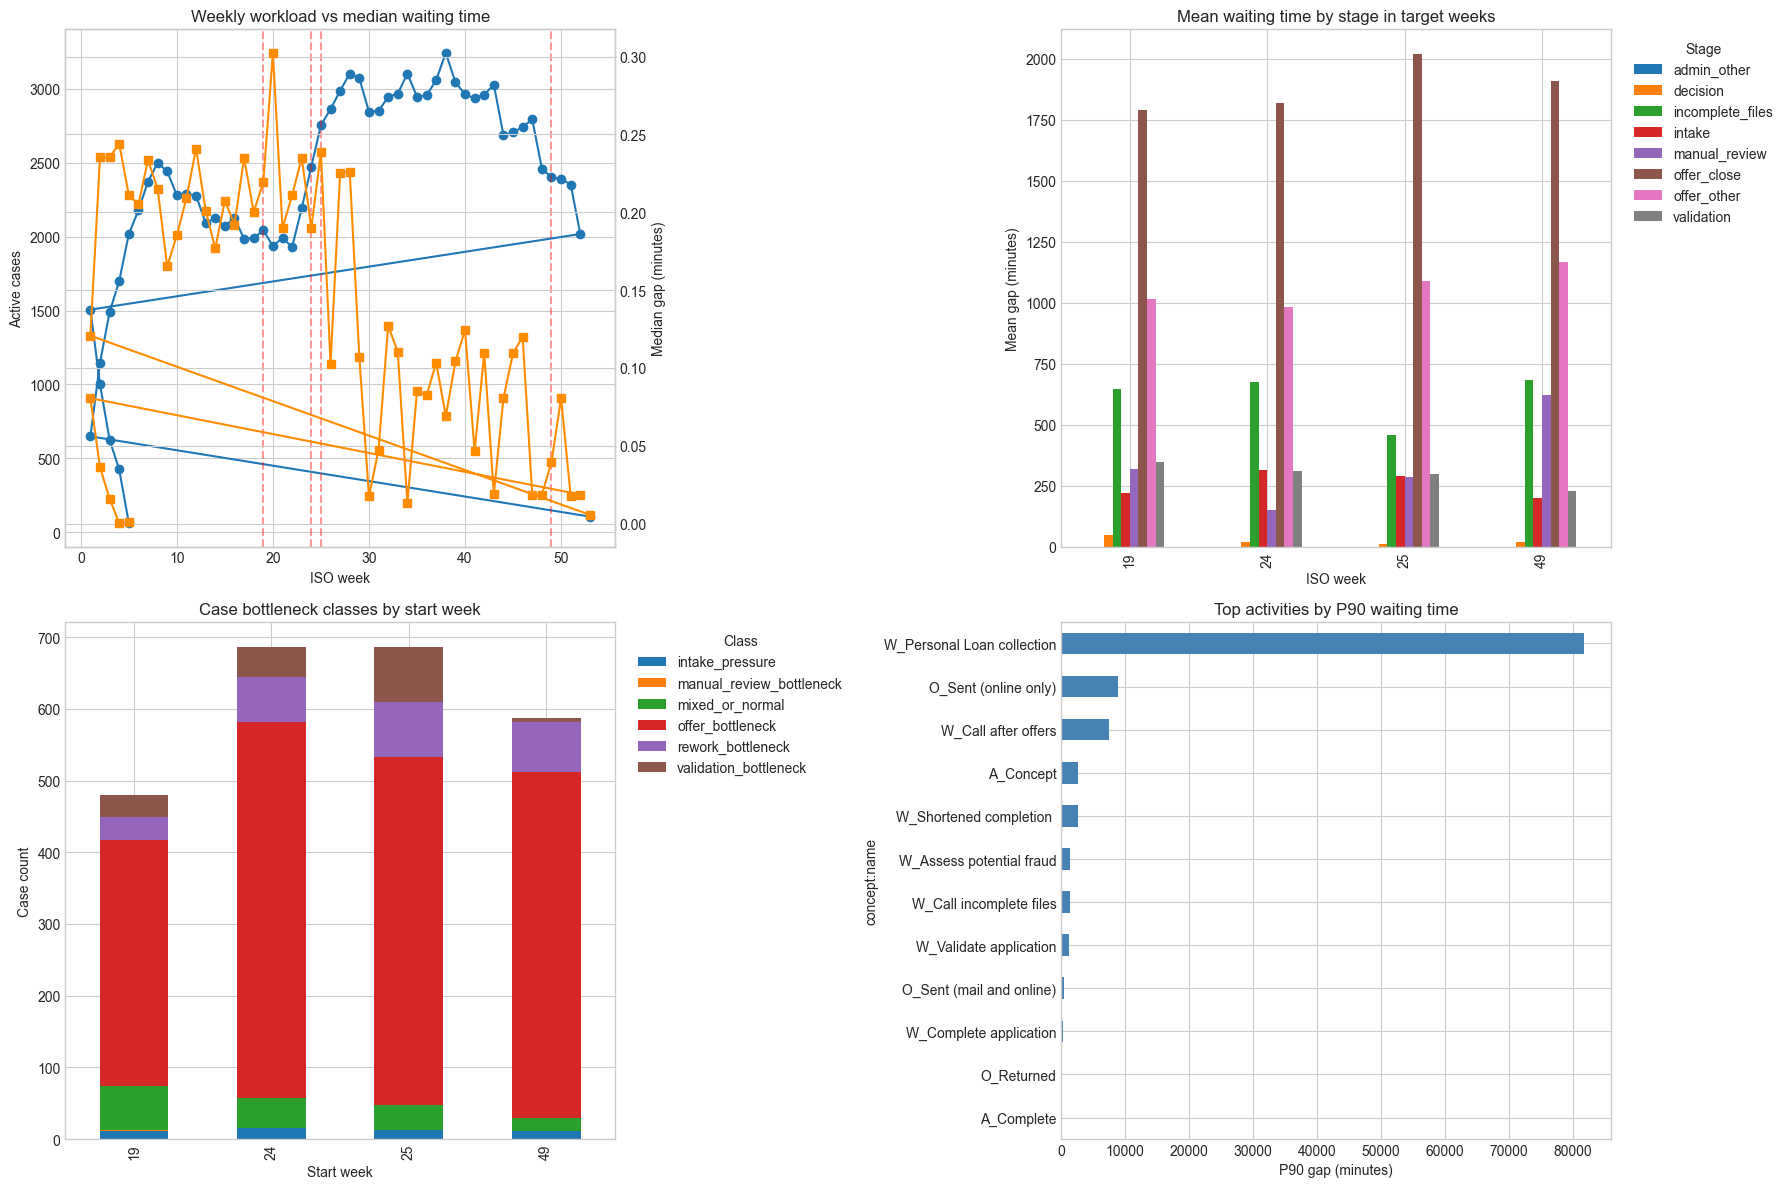

   year  week  events  cases  mean_gap_minutes  median_gap_minutes  \
0  2015    53     886    105        363.888903            0.005667   
1  2016     1    9901    648        636.997736            0.120717   
2  2016     2   15390   1092        863.589657            0.235217   
3  2016     3   16842   1219        721.460843            0.235383   
4  2016     4   18468   1444       1125.673948            0.244017   

   p90_gap_minutes  active_cases  
0      1347.570267           105  
1      1338.565247           648  
2      1180.735867          1147  
3      1260.363900          1489  
4      1462.266237          1700  


In [12]:
VALIDATION_ACTIVITIES = {
    "W_Validate application",
    "A_Validating",
    "O_Returned",
}

INCOMPLETE_ACTIVITIES = {
    "W_Call incomplete files",
    "A_Incomplete",
}

MANUAL_REVIEW_ACTIVITIES = {
    "W_Personal Loan collection",
    "W_Shortened completion",
    "W_Assess potential fraud",
}

OFFER_ACTIVITIES = {
    "O_Create Offer",
    "O_Created",
    "O_Sent",
    "O_Accepted",
    "O_Cancelled",
    "W_Call after offers",
    "A_Complete",
}

INTAKE_ACTIVITIES = {
    "A_Create Application",
    "A_Submitted",
    "W_Handle leads",
    "W_Complete application",
    "A_Concept",
}

DECISION_ACTIVITIES = {
    "A_Accepted",
    "A_Denied",
    "A_Pending",
}


def classify_stage(activity: str) -> str:
    if activity in VALIDATION_ACTIVITIES:
        return "validation"
    if activity in INCOMPLETE_ACTIVITIES:
        return "incomplete_files"
    if activity in MANUAL_REVIEW_ACTIVITIES:
        return "manual_review"
    if activity in OFFER_ACTIVITIES:
        return "offer_close"
    if activity in INTAKE_ACTIVITIES:
        return "intake"
    if activity in DECISION_ACTIVITIES:
        return "decision"
    if activity.startswith("W_"):
        return "manual_other"
    if activity.startswith("A_"):
        return "admin_other"
    if activity.startswith("O_"):
        return "offer_other"
    return "other"


def week_start_end(year: int, week: int):
    start = pd.Timestamp.fromisocalendar(int(year), int(week), 1).tz_localize("UTC")
    end = (
        pd.Timestamp.fromisocalendar(int(year), int(week), 7)
        + pd.Timedelta(days=1)
        - pd.Timedelta(microseconds=1)
    ).tz_localize("UTC")
    return start, end


def build_case_summary(frame: pd.DataFrame) -> pd.DataFrame:
    case_summary = frame.groupby("case:concept:name").agg(
        case_start=("time:timestamp", "min"),
        case_end=("time:timestamp", "max"),
        events=("time:timestamp", "size"),
        unique_activities=("concept:name", "nunique"),
    )
    case_summary["case_duration_hours"] = (
        case_summary["case_end"] - case_summary["case_start"]
    ).dt.total_seconds() / 3600
    case_summary["start_year"] = case_summary["case_start"].dt.isocalendar().year.astype(int)
    case_summary["start_week"] = case_summary["case_start"].dt.isocalendar().week.astype(int)
    return case_summary.reset_index()


def build_weekly_summary(frame: pd.DataFrame, case_summary: pd.DataFrame) -> pd.DataFrame:
    base = frame.groupby(["year", "week"]).agg(
        events=("concept:name", "size"),
        cases=("case:concept:name", "nunique"),
        mean_gap_minutes=("gap_minutes", "mean"),
        median_gap_minutes=("gap_minutes", "median"),
        p90_gap_minutes=("gap_minutes", lambda s: s.quantile(0.9)),
    ).reset_index()

    active_case_rows = []
    for _, row in base[["year", "week"]].drop_duplicates().iterrows():
        week_start, week_end = week_start_end(row["year"], row["week"])
        active_count = ((case_summary["case_start"] <= week_end) & (case_summary["case_end"] >= week_start)).sum()
        active_case_rows.append({"year": row["year"], "week": row["week"], "active_cases": active_count})

    active_cases = pd.DataFrame(active_case_rows)
    return base.merge(active_cases, on=["year", "week"], how="left")


def build_stage_summary(frame: pd.DataFrame) -> pd.DataFrame:
    stage_summary = frame.dropna(subset=["gap_minutes"]).groupby(["year", "week", "stage"]).agg(
        events=("gap_minutes", "size"),
        cases=("case:concept:name", "nunique"),
        mean_gap_minutes=("gap_minutes", "mean"),
        median_gap_minutes=("gap_minutes", "median"),
        p90_gap_minutes=("gap_minutes", lambda s: s.quantile(0.9)),
    ).reset_index()
    return stage_summary


def build_case_bottleneck(frame: pd.DataFrame, case_summary: pd.DataFrame) -> pd.DataFrame:
    working = frame.dropna(subset=["gap_minutes"]).copy()
    if working.empty:
        return pd.DataFrame()

    stage_gap = working.groupby(["case:concept:name", "stage"])["gap_minutes"].sum().reset_index()
    total_gap = working.groupby("case:concept:name")["gap_minutes"].sum().rename("total_gap_minutes").reset_index()

    dominant = stage_gap.sort_values(["case:concept:name", "gap_minutes"], ascending=[True, False])
    dominant = dominant.drop_duplicates("case:concept:name").rename(
        columns={"stage": "dominant_stage", "gap_minutes": "dominant_gap_minutes"}
    )

    repeat_counts = (
        frame.groupby(["case:concept:name", "concept:name"]).size().reset_index(name="count")
        .groupby("case:concept:name")["count"].max().rename("max_activity_repeat").reset_index()
    )

    case_level = (
        case_summary
        .merge(total_gap, on="case:concept:name", how="left")
        .merge(dominant[["case:concept:name", "dominant_stage", "dominant_gap_minutes"]], on="case:concept:name", how="left")
        .merge(repeat_counts, on="case:concept:name", how="left")
    )

    case_level["dominant_share"] = case_level["dominant_gap_minutes"] / case_level["total_gap_minutes"]
    case_level["dominant_share"] = case_level["dominant_share"].fillna(0)
    case_level["max_activity_repeat"] = case_level["max_activity_repeat"].fillna(0)

    def assign_bottleneck(row):
        if row["dominant_stage"] == "validation" and row["dominant_share"] >= 0.35:
            return "validation_bottleneck"
        if row["dominant_stage"] == "incomplete_files" and row["dominant_share"] >= 0.35:
            return "rework_bottleneck"
        if row["dominant_stage"] == "manual_review" and row["dominant_share"] >= 0.35:
            return "manual_review_bottleneck"
        if row["dominant_stage"] == "offer_close" and row["dominant_share"] >= 0.35:
            return "offer_bottleneck"
        if row["dominant_stage"] == "intake" and row["dominant_share"] >= 0.35:
            return "intake_pressure"
        return "mixed_or_normal"

    case_level["bottleneck_class"] = case_level.apply(assign_bottleneck, axis=1)
    return case_level


df["stage"] = df["concept:name"].map(classify_stage)
case_summary = build_case_summary(df)
weekly_summary = build_weekly_summary(df, case_summary)
stage_summary = build_stage_summary(df)
case_bottleneck = build_case_bottleneck(df, case_summary)

TARGET_WEEKS = [19, 24, 25, 49]
focus_weekly = weekly_summary[weekly_summary["week"].isin(TARGET_WEEKS)].copy()
focus_stage = stage_summary[stage_summary["week"].isin(TARGET_WEEKS)].copy()
focus_cases = case_bottleneck[case_bottleneck["start_week"].isin(TARGET_WEEKS)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
ax = axes[0, 0]
plot_weekly = weekly_summary.sort_values(["year", "week"]).copy()
ax.plot(plot_weekly["week"], plot_weekly["active_cases"], marker="o", label="Active cases")
ax2 = ax.twinx()
ax2.plot(plot_weekly["week"], plot_weekly["median_gap_minutes"], marker="s", color="darkorange", label="Median gap (min)")
ax.set_title("Weekly workload vs median waiting time")
ax.set_xlabel("ISO week")
ax.set_ylabel("Active cases")
ax2.set_ylabel("Median gap (minutes)")
for week in TARGET_WEEKS:
    ax.axvline(week, color="red", linestyle="--", alpha=0.4)
ax = axes[0, 1]
stage_pivot = focus_stage.pivot_table(index="week", columns="stage", values="mean_gap_minutes", aggfunc="mean")
stage_pivot.plot(kind="bar", ax=ax)
ax.set_title("Mean waiting time by stage in target weeks")
ax.set_xlabel("ISO week")
ax.set_ylabel("Mean gap (minutes)")
ax.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
ax = axes[1, 0]
class_mix = focus_cases.groupby(["start_week", "bottleneck_class"]).size().unstack(fill_value=0).sort_index()
class_mix.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Case bottleneck classes by start week")
ax.set_xlabel("Start week")
ax.set_ylabel("Case count")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
ax = axes[1, 1]
activity_wait = (
    df.dropna(subset=["gap_minutes"])
    .groupby("concept:name")
    .agg(
        events=("gap_minutes", "size"),
        mean_gap_minutes=("gap_minutes", "mean"),
        median_gap_minutes=("gap_minutes", "median"),
        p90_gap_minutes=("gap_minutes", lambda s: s.quantile(0.9)),
    )
    .sort_values("p90_gap_minutes", ascending=False)
)
activity_wait.head(12)["p90_gap_minutes"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top activities by P90 waiting time")
ax.set_xlabel("P90 gap (minutes)")

plt.tight_layout()
plt.show()

print(weekly_summary.head())

In [13]:
def build_case_bottleneck(frame: pd.DataFrame, case_summary: pd.DataFrame) -> pd.DataFrame:
    working = frame.dropna(subset=["gap_minutes"]).copy()
    if working.empty:
        return pd.DataFrame()

    stage_gap = working.groupby(["case:concept:name", "stage"])["gap_minutes"].sum().reset_index()
    total_gap = working.groupby("case:concept:name")["gap_minutes"].sum().rename("total_gap_minutes").reset_index()

    dominant = stage_gap.sort_values(["case:concept:name", "gap_minutes"], ascending=[True, False])
    dominant = dominant.drop_duplicates("case:concept:name").rename(
        columns={"stage": "dominant_stage", "gap_minutes": "dominant_gap_minutes"}
    )

    repeat_counts = (
        frame.groupby(["case:concept:name", "concept:name"]).size().reset_index(name="count")
        .groupby("case:concept:name")["count"].max().rename("max_activity_repeat").reset_index()
    )

    lifecycle_counts = frame["lifecycle:transition"].value_counts(normalize=True).rename("share").reset_index()
    lifecycle_counts.columns = ["lifecycle:transition", "share"]

    case_level = (
        case_summary
        .merge(total_gap, on="case:concept:name", how="left")
        .merge(dominant[["case:concept:name", "dominant_stage", "dominant_gap_minutes"]], on="case:concept:name", how="left")
        .merge(repeat_counts, on="case:concept:name", how="left")
    )

    case_level["dominant_share"] = case_level["dominant_gap_minutes"] / case_level["total_gap_minutes"]
    case_level["dominant_share"] = case_level["dominant_share"].fillna(0)
    case_level["max_activity_repeat"] = case_level["max_activity_repeat"].fillna(0)

    def assign_bottleneck(row):
        if row["dominant_stage"] == "validation" and row["dominant_share"] >= 0.35:
            return "validation_bottleneck"
        if row["dominant_stage"] == "incomplete_files" and row["dominant_share"] >= 0.35:
            return "rework_bottleneck"
        if row["dominant_stage"] == "offer_close" and row["dominant_share"] >= 0.35:
            return "offer_bottleneck"
        if row["dominant_stage"] == "intake" and row["dominant_share"] >= 0.35:
            return "intake_pressure"
        return "mixed_or_normal"

    case_level["bottleneck_class"] = case_level.apply(assign_bottleneck, axis=1)
    return case_level


case_bottleneck = build_case_bottleneck(df, case_summary)

TARGET_WEEKS = [19, 24, 25, 49]
focus_weekly = weekly_summary[weekly_summary["week"].isin(TARGET_WEEKS)].copy()
focus_stage = stage_summary[stage_summary["week"].isin(TARGET_WEEKS)].copy()
focus_cases = case_bottleneck[case_bottleneck["start_week"].isin(TARGET_WEEKS)].copy()

print("Focus weekly summary")
print(focus_weekly.sort_values(["year", "week"]).to_string(index=False))

print("\nFocus stage summary")
print(
    focus_stage.sort_values(["year", "week", "mean_gap_minutes"], ascending=[True, True, False])
    .to_string(index=False)
)

print("\nBottleneck class counts in target weeks")
print(
    focus_cases.groupby(["start_week", "bottleneck_class"]).size().unstack(fill_value=0).sort_index().to_string()
)

print("\nTop bottleneck cases")
print(
    focus_cases.sort_values(["dominant_gap_minutes", "case_duration_hours"], ascending=False)
    .head(20)
    .to_string(index=False)
)

Focus weekly summary
 year  week  events  cases  mean_gap_minutes  median_gap_minutes  p90_gap_minutes  active_cases
 2016    19   20529   1559        731.201842            0.219350      1178.925510          2044
 2016    24   23310   1872        795.692512            0.189900      1428.569230          2475
 2016    25   26198   2165        840.701531            0.238733      1367.100293          2755
 2016    49   24251   1749        788.585252            0.039500      1268.403453          2401

Focus stage summary
 year  week            stage  events  cases  mean_gap_minutes  median_gap_minutes  p90_gap_minutes
 2016    19      offer_close    4891   1300       1789.017864            0.176800      5552.450933
 2016    19      offer_other     677    578       1014.507015            0.000300         4.354713
 2016    19 incomplete_files    3479    418        645.969352            0.944933      1127.779810
 2016    19       validation    5631    622        345.550710            0.434450 

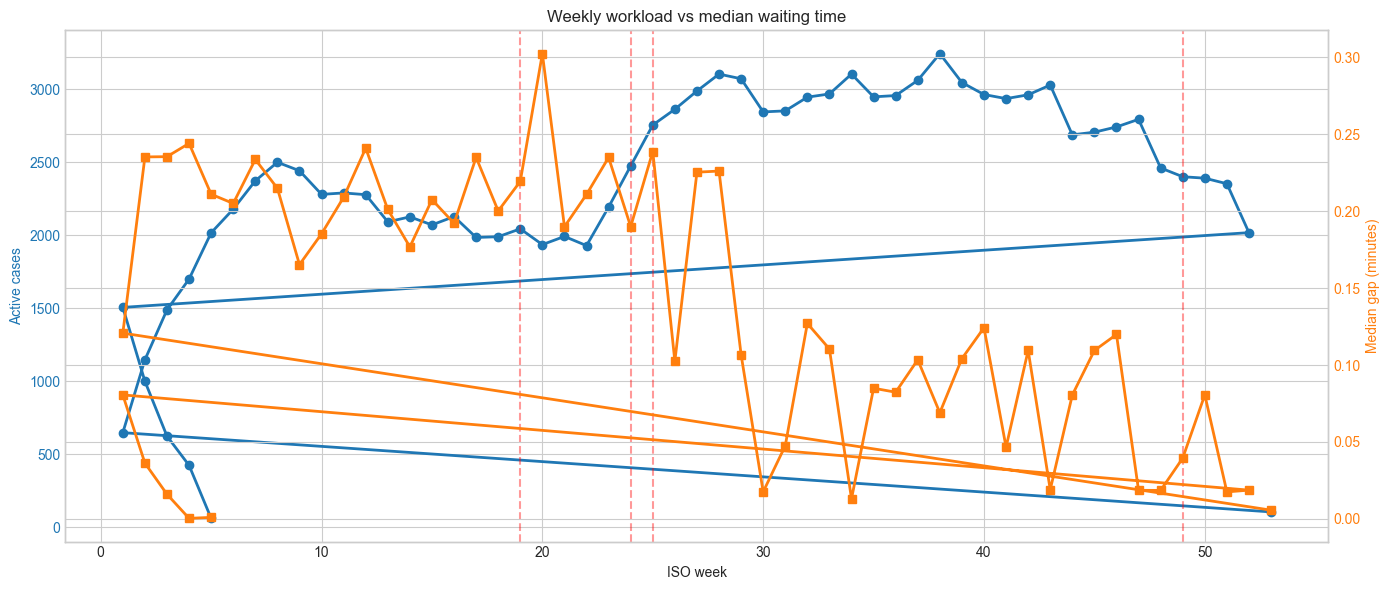


=== NHẬN XÉT BIỂU ĐỒ 1: WORKLOAD VS WAITING TIME ===
- Tuần có active cases cao nhất trong nhóm mục tiêu: tuần 25 (2755 cases).
- Tuần có median waiting cao nhất: tuần 25 (0.239 phút).
- Tuần có median waiting thấp nhất: tuần 49 (0.040 phút).
- Diễn giải: nếu active cases cao mà median waiting không tăng tương ứng thì bottleneck có xu hướng cục bộ theo stage, không phải nghẽn toàn hệ thống.


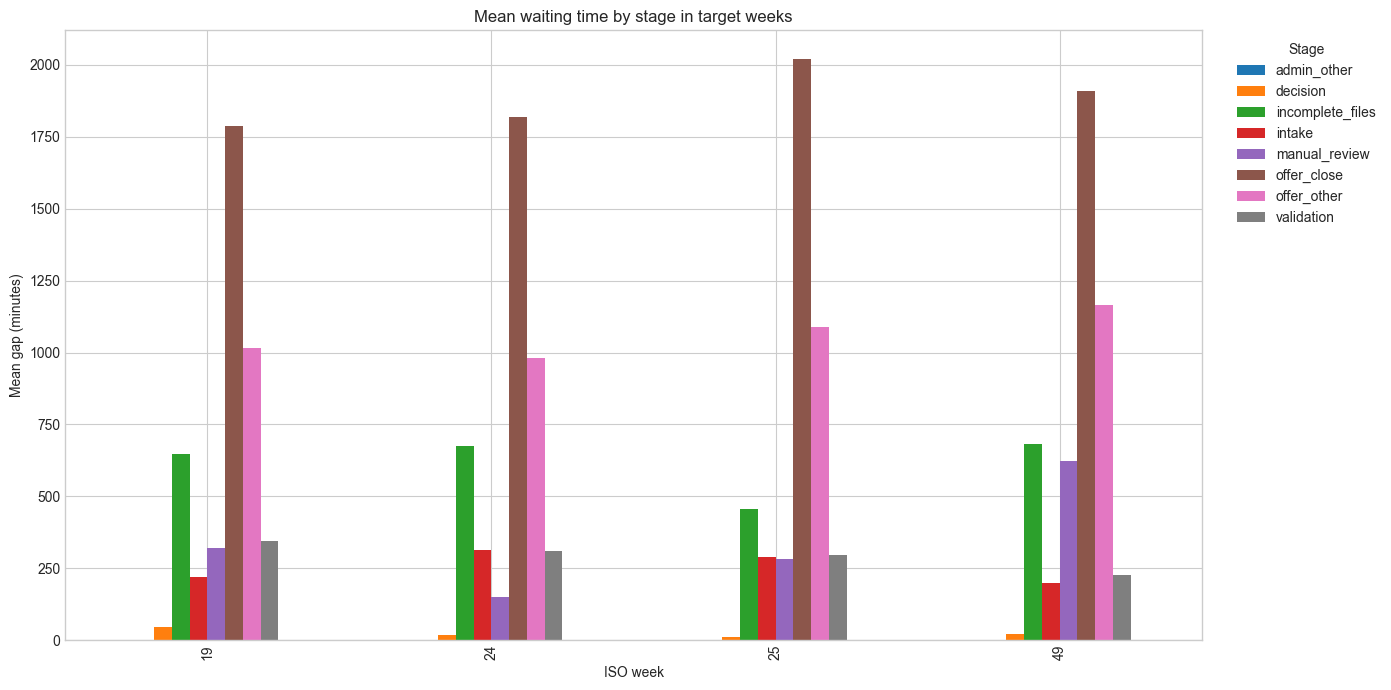


=== NHẬN XÉT BIỂU ĐỒ 2: STAGE WAITING TIME ===
- Tuần 19: nghẽn chính ở stage offer_close (1789.0 phút), kế tiếp là offer_other (1014.5 phút).
- Tuần 24: nghẽn chính ở stage offer_close (1819.2 phút), kế tiếp là offer_other (982.3 phút).
- Tuần 25: nghẽn chính ở stage offer_close (2019.1 phút), kế tiếp là offer_other (1088.3 phút).
- Tuần 49: nghẽn chính ở stage offer_close (1909.5 phút), kế tiếp là offer_other (1165.8 phút).
- Diễn giải: stage đứng đầu lặp lại qua nhiều tuần chính là điểm nghẽn cấu trúc của quy trình.


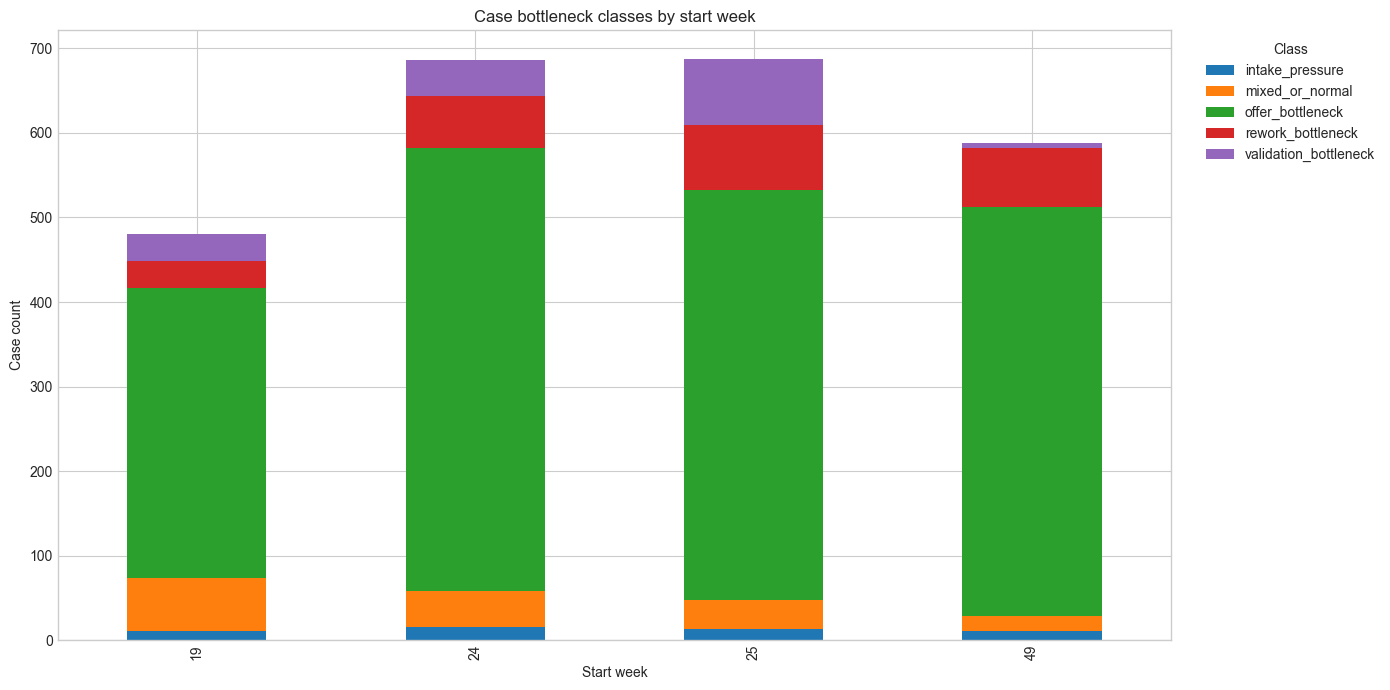


=== NHẬN XÉT BIỂU ĐỒ 3: BOTTLENECK CLASS MIX ===
- Tuần 19: class chiếm ưu thế là offer_bottleneck (71.5% số cases).
- Tuần 24: class chiếm ưu thế là offer_bottleneck (76.4% số cases).
- Tuần 25: class chiếm ưu thế là offer_bottleneck (70.6% số cases).
- Tuần 49: class chiếm ưu thế là offer_bottleneck (82.1% số cases).
- Diễn giải: class nào chiếm tỷ trọng cao ổn định là class cần ưu tiên xử lý trước trong cải tiến quy trình.


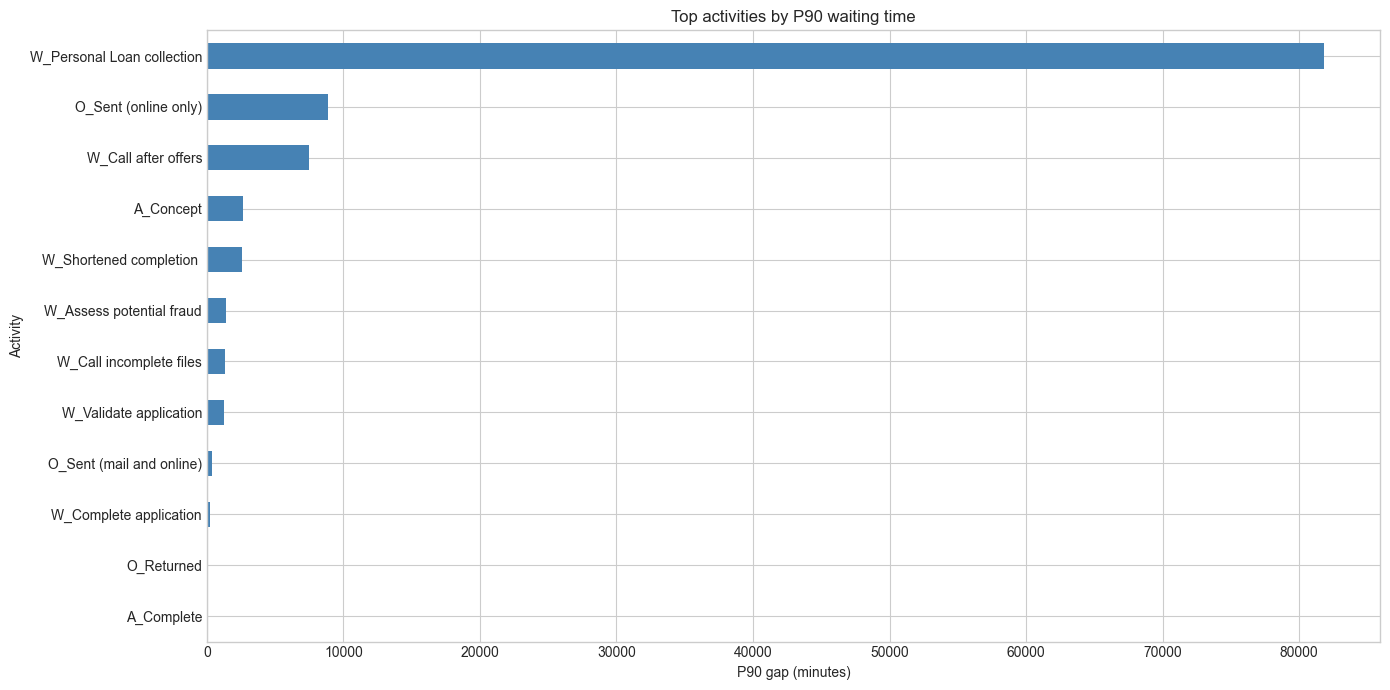


=== NHẬN XÉT BIỂU ĐỒ 4: TOP ACTIVITIES P90 WAITING ===
- W_Personal Loan collection: P90=81832.1 phút, Median=0.391 phút, Events=20.
- O_Sent (online only): P90=8841.5 phút, Median=4.443 phút, Events=2016.
- W_Call after offers: P90=7477.0 phút, Median=0.270 phút, Events=181445.
- A_Concept: P90=2675.2 phút, Median=81.562 phút, Events=31486.
- W_Shortened completion : P90=2588.9 phút, Median=0.046 phút, Events=233.
- Diễn giải: activity có P90 rất cao là nguồn tạo tail-delay và gây cảm giác nghẽn mạnh ở một phần case.

Saved figures:
..\results\bottleneck_analysis\01_weekly_workload_vs_waiting.png
..\results\bottleneck_analysis\02_stage_waiting_time_target_weeks.png
..\results\bottleneck_analysis\03_bottleneck_class_mix.png
..\results\bottleneck_analysis\04_top_activities_p90_waiting.png


In [14]:
# Plot 1: Weekly workload vs waiting time
plot_weekly = weekly_summary.sort_values(["year", "week"]).copy()
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(plot_weekly["week"], plot_weekly["active_cases"], marker="o", linewidth=2, label="Active cases", color="tab:blue")
ax1.set_title("Weekly workload vs median waiting time")
ax1.set_xlabel("ISO week")
ax1.set_ylabel("Active cases", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax1b = ax1.twinx()
ax1b.plot(plot_weekly["week"], plot_weekly["median_gap_minutes"], marker="s", linewidth=2, label="Median gap (min)", color="tab:orange")
ax1b.set_ylabel("Median gap (minutes)", color="tab:orange")
ax1b.tick_params(axis="y", labelcolor="tab:orange")

for week in TARGET_WEEKS:
    ax1.axvline(week, color="red", linestyle="--", alpha=0.4)

fig1.tight_layout()
fig1.savefig(OUTPUT_DIR / "01_weekly_workload_vs_waiting.png", dpi=150, bbox_inches="tight")
plt.show()

# Nhận xét cho biểu đồ 1
focus_weekly_plot = plot_weekly[plot_weekly["week"].isin(TARGET_WEEKS)].copy()
if not focus_weekly_plot.empty:
    max_active_row = focus_weekly_plot.loc[focus_weekly_plot["active_cases"].idxmax()]
    max_gap_row = focus_weekly_plot.loc[focus_weekly_plot["median_gap_minutes"].idxmax()]
    min_gap_row = focus_weekly_plot.loc[focus_weekly_plot["median_gap_minutes"].idxmin()]

    print("\n=== NHẬN XÉT BIỂU ĐỒ 1: WORKLOAD VS WAITING TIME ===")
    print(
        f"- Tuần có active cases cao nhất trong nhóm mục tiêu: tuần {int(max_active_row['week'])} "
        f"({int(max_active_row['active_cases'])} cases)."
    )
    print(
        f"- Tuần có median waiting cao nhất: tuần {int(max_gap_row['week'])} "
        f"({max_gap_row['median_gap_minutes']:.3f} phút)."
    )
    print(
        f"- Tuần có median waiting thấp nhất: tuần {int(min_gap_row['week'])} "
        f"({min_gap_row['median_gap_minutes']:.3f} phút)."
    )
    print("- Diễn giải: nếu active cases cao mà median waiting không tăng tương ứng thì bottleneck có xu hướng cục bộ theo stage, không phải nghẽn toàn hệ thống.")

# Plot 2: Mean waiting time by stage in target weeks
stage_pivot = focus_stage.pivot_table(index="week", columns="stage", values="mean_gap_minutes", aggfunc="mean")
fig2, ax2 = plt.subplots(figsize=(14, 7))
stage_pivot.plot(kind="bar", ax=ax2)
ax2.set_title("Mean waiting time by stage in target weeks")
ax2.set_xlabel("ISO week")
ax2.set_ylabel("Mean gap (minutes)")
ax2.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "02_stage_waiting_time_target_weeks.png", dpi=150, bbox_inches="tight")
plt.show()

# Nhận xét cho biểu đồ 2
print("\n=== NHẬN XÉT BIỂU ĐỒ 2: STAGE WAITING TIME ===")
if stage_pivot.empty:
    print("- Không có dữ liệu stage cho các tuần mục tiêu.")
else:
    for week in stage_pivot.index:
        row = stage_pivot.loc[week].dropna().sort_values(ascending=False)
        if len(row) == 0:
            continue
        top_stage = row.index[0]
        top_value = row.iloc[0]
        second_text = ""
        if len(row) > 1:
            second_text = f", kế tiếp là {row.index[1]} ({row.iloc[1]:.1f} phút)"
        print(f"- Tuần {int(week)}: nghẽn chính ở stage {top_stage} ({top_value:.1f} phút){second_text}.")
    print("- Diễn giải: stage đứng đầu lặp lại qua nhiều tuần chính là điểm nghẽn cấu trúc của quy trình.")

# Plot 3: Case bottleneck class distribution by week
class_mix = focus_cases.groupby(["start_week", "bottleneck_class"]).size().unstack(fill_value=0).sort_index()
fig3, ax3 = plt.subplots(figsize=(14, 7))
class_mix.plot(kind="bar", stacked=True, ax=ax3)
ax3.set_title("Case bottleneck classes by start week")
ax3.set_xlabel("Start week")
ax3.set_ylabel("Case count")
ax3.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
fig3.tight_layout()
fig3.savefig(OUTPUT_DIR / "03_bottleneck_class_mix.png", dpi=150, bbox_inches="tight")
plt.show()

# Nhận xét cho biểu đồ 3
print("\n=== NHẬN XÉT BIỂU ĐỒ 3: BOTTLENECK CLASS MIX ===")
if class_mix.empty:
    print("- Không có dữ liệu phân loại bottleneck theo tuần mục tiêu.")
else:
    class_share = class_mix.div(class_mix.sum(axis=1), axis=0)
    for week in class_share.index:
        row = class_share.loc[week].sort_values(ascending=False)
        top_class = row.index[0]
        top_share = row.iloc[0] * 100
        print(f"- Tuần {int(week)}: class chiếm ưu thế là {top_class} ({top_share:.1f}% số cases).")
    print("- Diễn giải: class nào chiếm tỷ trọng cao ổn định là class cần ưu tiên xử lý trước trong cải tiến quy trình.")

# Plot 4: Top activities by P90 waiting time
activity_wait = (
    df.dropna(subset=["gap_minutes"])
    .groupby("concept:name")
    .agg(
        events=("gap_minutes", "size"),
        mean_gap_minutes=("gap_minutes", "mean"),
        median_gap_minutes=("gap_minutes", "median"),
        p90_gap_minutes=("gap_minutes", lambda s: s.quantile(0.9)),
    )
    .sort_values("p90_gap_minutes", ascending=False)
)

fig4, ax4 = plt.subplots(figsize=(14, 7))
activity_wait.head(12)["p90_gap_minutes"].sort_values().plot(kind="barh", ax=ax4, color="steelblue")
ax4.set_title("Top activities by P90 waiting time")
ax4.set_xlabel("P90 gap (minutes)")
ax4.set_ylabel("Activity")
fig4.tight_layout()
fig4.savefig(OUTPUT_DIR / "04_top_activities_p90_waiting.png", dpi=150, bbox_inches="tight")
plt.show()

# Nhận xét cho biểu đồ 4
print("\n=== NHẬN XÉT BIỂU ĐỒ 4: TOP ACTIVITIES P90 WAITING ===")
if activity_wait.empty:
    print("- Không có dữ liệu activity waiting.")
else:
    top5 = activity_wait.head(5).reset_index()
    for _, row in top5.iterrows():
        print(
            f"- {row['concept:name']}: P90={row['p90_gap_minutes']:.1f} phút, "
            f"Median={row['median_gap_minutes']:.3f} phút, Events={int(row['events'])}."
        )
    print("- Diễn giải: activity có P90 rất cao là nguồn tạo tail-delay và gây cảm giác nghẽn mạnh ở một phần case.")

print("\nSaved figures:")
print(OUTPUT_DIR / "01_weekly_workload_vs_waiting.png")
print(OUTPUT_DIR / "02_stage_waiting_time_target_weeks.png")
print(OUTPUT_DIR / "03_bottleneck_class_mix.png")
print(OUTPUT_DIR / "04_top_activities_p90_waiting.png")

- W_Personal Loan collection là nghẽn kiểu outlier (ít nhưng cực dài).
- O_Sent (online only) là nghẽn có ảnh hưởng rộng hơn vì vừa dài vừa có tần suất đáng kể.
- W_Call after offers là nghẽn long-tail theo khối lượng lớn.